<a href="https://colab.research.google.com/github/Pratikshapawar-star/python-internship-practice-code/blob/main/Day8DT_Renewable_Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

In [ ]:
data =pd.read_csv("/content/Renewable_Energy_Adoption.csv")
data.head()

,carbon_emissions,energy_output,renewability_index,cost_efficiency,adoption
0,181.089042,128.286267,0.642032,0.732568,1
1,382.750007,672.769370,0.084140,2.891096,0
2,306.197880,382.920383,0.161629,2.932858,0
3,259.530469,557.713622,0.898554,3.368435,0
4,104.606524,916.809827,0.606429,3.767411,0


In [ ]:
data.shape

(100, 5)

In [ ]:
data.size

500

In [ ]:
data.isnull().sum()

,0
carbon_emissions,0
energy_output,0
renewability_index,0
cost_efficiency,0
adoption,0


In [ ]:
data["adoption"].value_counts()

,count
adoption,
0,85
1,15


In [ ]:
plt.scatter(data=["carbon_emissions"],data=["energy_output"], c data=["adoption"])
plt.xlabel("carbon_emissions")
plt.ylabel("adoption")
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (ipython-input-1653462184.py, line 1)

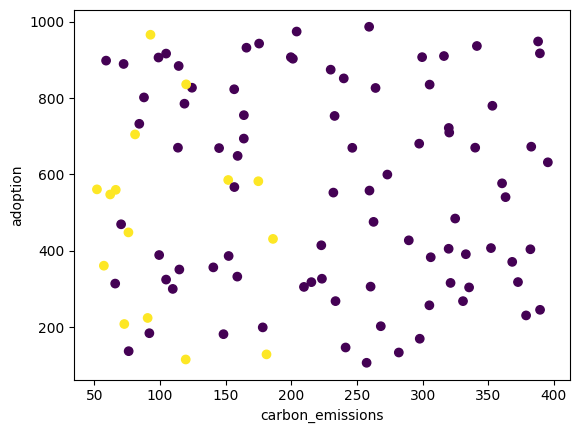

In [ ]:
plt.scatter(data['carbon_emissions'], data['energy_output'],c=data['adoption'])
plt.xlabel('carbon_emissions')
plt.ylabel('adoption')
plt.show()

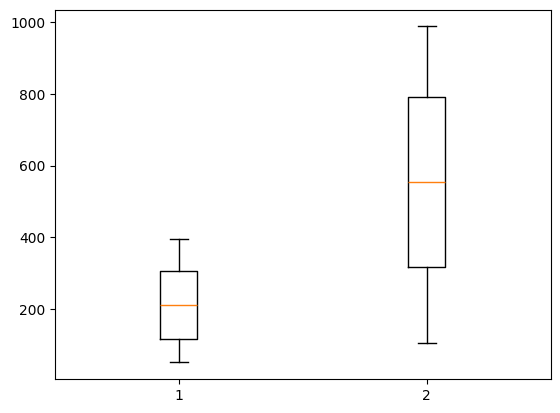

In [ ]:
plt.boxplot([data['carbon_emissions'],data['energy_output']])
plt.show()

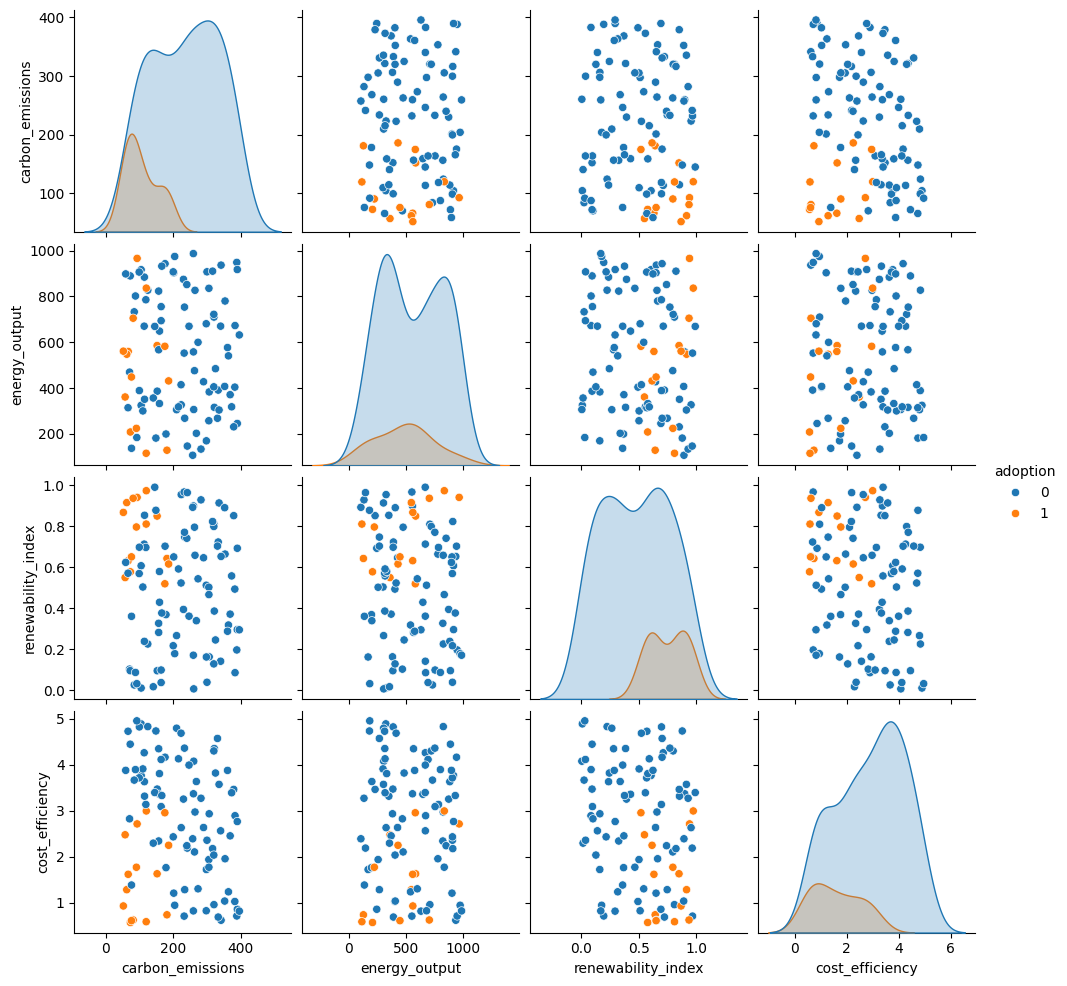

In [ ]:
sns.pairplot(data, hue='adoption')
plt.show()

In [ ]:
x=data[['carbon_emissions','energy_output','renewability_index', 'cost_efficiency']]
y=data['adoption']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=42)


In [ ]:
model=DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)

accuracy: 0.85


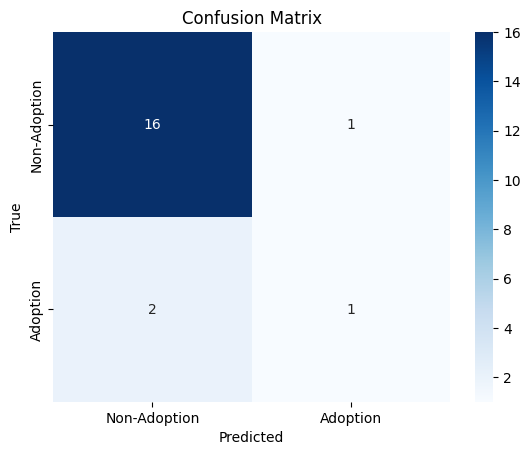

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Adoption', 'Adoption'],
            yticklabels=['Non-Adoption', 'Adoption'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test,y_pred,target_names=['Non-Adoption','Adoption']))

              precision    recall  f1-score   support

Non-Adoption       0.89      0.94      0.91        17
    Adoption       0.50      0.33      0.40         3

    accuracy                           0.85        20
   macro avg       0.69      0.64      0.66        20
weighted avg       0.83      0.85      0.84        20



In [ ]:
import joblib
joblib.dump(model,'Renewable_Energy_Adoption_model.pkl')

['Renewable_Energy_Adoption_model.pkl']

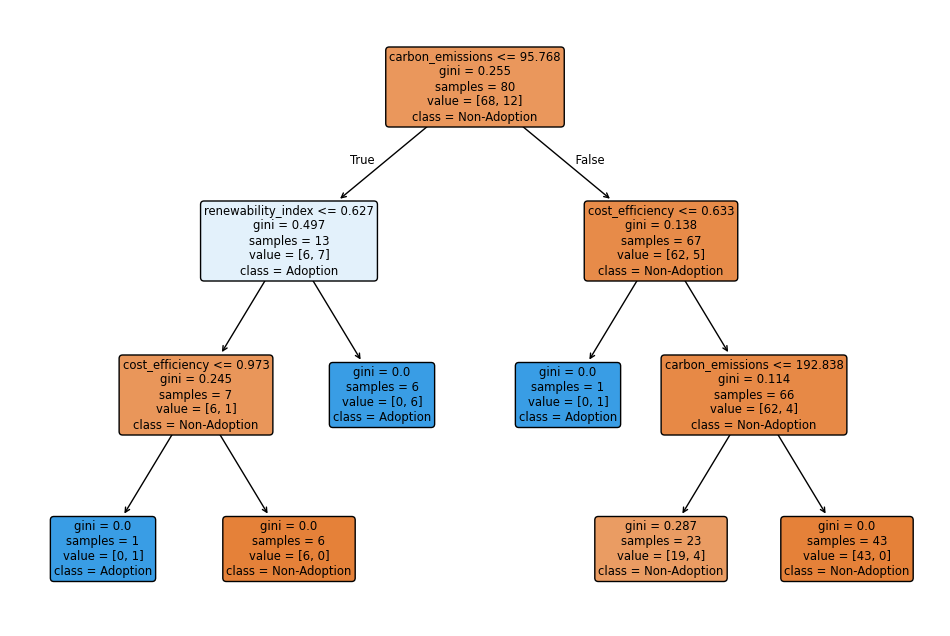

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(model,feature_names=x.columns,class_names=['Non-Adoption','Adoption'],filled=True,rounded=True)
plt.savefig('dt1.png')
plt.show()